# Feature and Model Selection

In [10]:
import seaborn as sns
import warnings
import joblib
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# Classical ML models
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Gradient boosting libraries
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import sys 
sys.path.append('..')  

from module.dataload import DPN_data
import ymlconfig
from utils2.selection import *

%matplotlib inline
%load_ext autoreload
%autoreload 2

warnings.filterwarnings('ignore')
np.set_printoptions(precision=3)  # decimal places for outputs from numpy
pd.set_option("display.precision", 3)  # decimal places for outputs from pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


----

## Read Config File

In [11]:
config_path = Path(r'experiments\binary')
config_file = config_path / "selection_config_dev.yml"
config_dict = ymlconfig.load_config(config_file)
config = ymlconfig.dict_to_namespace(config_dict)
config_dict

{'experiment': {'summary': 'binary classification - feature  and model selection (development experiment)',
  'classification_type': 'binary',
  'stage': 'feature_model_selection',
  'tag': 'development',
  'verbosity': 1,
  'random_seed': 42},
 'data': {'dataset_path': '../dataset/Sudoscan Working File with Stats.xlsx'},
 'feature_selection': {'cross_validation': {'k_splits': 3,
   'n_repeats': 3,
   'scoring': 'youden'},
  'vif_threshold': 5,
  'figures': {'youden_table_topk': 5}}}

## Data Loading

In [12]:
D = DPN_data(config.data.dataset_path)
D.load(classification=config.experiment.classification_type);
D.df.tail(3)

,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
187,1,36.0,0,1.0,1.0,6.18,1,0,0,1,0,0,1,0,1,3.0,11.45,49.2,13.79,40.2,41.8,3.60,11.94,8.78,50.3,14.11,43.1,14.95,41.2,42.2,3.7,9.43,7.19,49.9,69.0,4.0,56.0,8.0,83.0,7.0,0
188,0,60.0,1,5.0,1.0,12.20,1,0,1,0,0,1,1,1,1,8.0,5.03,37.9,0.00,0.0,36.3,4.85,5.05,3.06,53.1,5.58,37.2,0.00,0.0,32.2,4.2,5.09,3.28,53.5,16.0,11.0,21.0,9.0,46.0,32.0,1
189,0,65.0,1,15.0,1.0,7.59,1,1,0,1,0,1,1,1,1,8.0,0.00,0.0,0.00,0.0,43.2,5.80,0.56,0.20,0.0,0.00,0.0,0.00,0.0,48.1,5.7,0.27,0.11,0.0,39.0,16.0,41.0,23.0,43.0,44.0,1


Binary Classification Classes:  ['Negative', 'Possible', 'Probable'] vs 'Confirmed'


In [13]:
dfdpn = D.df
data_cols = dfdpn.drop(D.non_data_cols, axis=1, errors="ignore").columns
len(data_cols), data_cols

(40,
 Index(['SEX', 'AGE', 'SUBJ', 'DM_DUR', 'INSULIN', 'HBA1C', 'HPN', 'PAOD',
        'DSLPDMIA', 'CKD', 'GBS', 'DEC_VS', 'DEC_PPS', 'DEC_LTS', 'DEC_AR',
        'MNSI', 'SSA_L', 'SSC_L', 'SPSA_L', 'SPSC_L', 'MCV_L', 'DL_L',
        'CMAPANK_L', 'CMAPKNE_L', 'FWAVE_L', 'SSA_R', 'SSC_R', 'SPSA_R',
        'SPSC_R', 'MCV_R', 'DL_R', 'CMAPANK_R', 'CMAPKNE_R', 'FWAVE_R',
        'FEET_MEAN_ESC', 'FEET_PCT_ASYM', 'HAND_MEAN_ESC', 'HAND_PCT_ASYM',
        'NS', 'CAS'],
       dtype='object'))

### Data Inspection

In [14]:
X = dfdpn[data_cols]
y = dfdpn['Confirmed_Binary_DPN']
X.shape, y.shape

((190, 40), (190,))

In [15]:
# get number of postive and negative class
print('Confirmed - positive class', y.sum())
print('Non-confirmed - negative class', y.shape[0]-y.sum())

Confirmed - positive class 130
Non-confirmed - negative class 60


----

## Global Variables

In [16]:
model_metrics = {}  # key: experiment code, value: {model: <string> (e.g. all, ncs), rcv_cores: <Dataframe> Perfomance metrics of repeated k-fold of algorithms}
metrics_stats = {}   # key: experiment code, value: {stat: <string> (e.g. mean, std), stat (mean/std) of the performance of all algorithms}
youden_scores  = {} # key: experiment code, value: list of youden cv scores algorithms

In [32]:
random_seed = config.experiment.random_seed
verbosity = config.experiment.verbosity

k_splits = config.feature_selection.cross_validation.k_splits
n_repeats = config.feature_selection.cross_validation.n_repeats
scoring = config.feature_selection.cross_validation.scoring
vif_threshold = config.feature_selection.vif_threshold
experiment_tag = config.experiment.tag

outputdir = config_path /  config.experiment.stage
outputdir.mkdir(parents=True, exist_ok=True)
print(outputdir)

experiments\binary\feature_model_selection


## Iterative Group Feature Elimination

----

### All Features

In [18]:
model_metrics['all'] = benchmark_models(X, y, k_splits, n_repeats, random_seed, 1, experiment_tag) # 1 = verbosity

⏩ Naive: No scaling applied.
⚙️ Logistic Regression: Scaling continuous cols with StandardScaler


In [19]:
model_metrics['all'] # list of dictionary with 2 keys, model and scores (a dataframe)

[{'model': 'Naive',
  'rcv_scores':    Accuracy  Precision  Sensitivity  Specificity  Youden Index     F1  ROC-AUC
  0     0.688      0.688          1.0          0.0           0.0  0.815      0.5
  1     0.683      0.683          1.0          0.0           0.0  0.811      0.5
  2     0.683      0.683          1.0          0.0           0.0  0.811      0.5
  3     0.688      0.688          1.0          0.0           0.0  0.815      0.5
  4     0.683      0.683          1.0          0.0           0.0  0.811      0.5
  5     0.683      0.683          1.0          0.0           0.0  0.811      0.5
  6     0.688      0.688          1.0          0.0           0.0  0.815      0.5
  7     0.683      0.683          1.0          0.0           0.0  0.811      0.5
  8     0.683      0.683          1.0          0.0           0.0  0.811      0.5},
 {'model': 'Logistic Regression',
  'rcv_scores':    Accuracy  Precision  Sensitivity  Specificity  Youden Index     F1  ROC-AUC
  0     0.938      0.976 

In [20]:
model_metrics.keys() # only experiment named 'all'  loaded so far 

dict_keys(['all'])

In [21]:
len(model_metrics['all']) # 16 algorithms

2

In [22]:
model_metrics['all'][0]['model'] # Get model name of algo 0

'Naive'

In [23]:
# get scores for algo 0 (naive)   
# expect k*N_REPEATS rows (e.g. 10 for k=5, NREPEATS=2)

model_metrics['all'][0]['rcv_scores'] 

,Accuracy,Precision,Sensitivity,Specificity,Youden Index,F1,ROC-AUC
0,0.688,0.688,1.0,0.0,0.0,0.815,0.5
1,0.683,0.683,1.0,0.0,0.0,0.811,0.5
2,0.683,0.683,1.0,0.0,0.0,0.811,0.5
3,0.688,0.688,1.0,0.0,0.0,0.815,0.5
4,0.683,0.683,1.0,0.0,0.0,0.811,0.5
5,0.683,0.683,1.0,0.0,0.0,0.811,0.5
6,0.688,0.688,1.0,0.0,0.0,0.815,0.5
7,0.683,0.683,1.0,0.0,0.0,0.811,0.5
8,0.683,0.683,1.0,0.0,0.0,0.811,0.5


In [24]:
metrics_stats['all'] = calculate_metric_statistics(model_metrics['all'])

In [25]:
metrics_stats['all']['mean']

,Accuracy,Precision,Sensitivity,Specificity,Youden Index,F1,ROC-AUC
Logistic Regression,0.875,0.904,0.915,0.789,0.704,0.910,0.924
Naive,0.684,0.684,1.000,0.000,0.000,0.812,0.500


In [26]:
metrics_stats['all']['std']

,Accuracy,Precision,Sensitivity,Specificity,Youden Index,F1,ROC-AUC
Logistic Regression,0.059,0.049,0.046,0.108,0.142,0.044,0.044
Naive,0.002,0.002,0.000,0.000,0.000,0.002,0.000


In [27]:
youden_scores['all'] = get_youden_scores(model_metrics, 'all', metrics_stats)
youden_scores['all']

,Logistic Regression,Naive
0,0.882,0.0
1,0.680,0.0
2,0.607,0.0
3,0.614,0.0
4,0.680,0.0
5,0.587,0.0
6,0.682,0.0
7,0.607,0.0
8,1.000,0.0


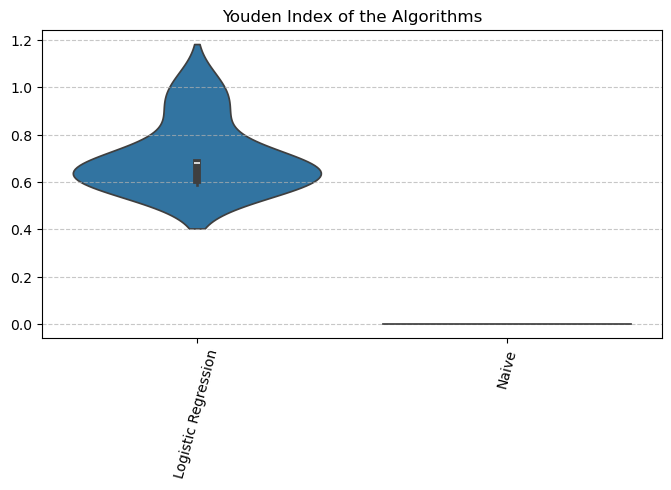

In [28]:
plot_youden_scores(youden_scores, 'all', 'Youden Index of the Algorithms', savedir=outputdir)

In [30]:
from utils2.selection import *

### No Collinear Features

In [ ]:
high_vif = get_high_vif(X, vif_threshold, verbosity)

Features with VIF higher than 5
      feature      VIF
0       const  433.829
17      SSA_L    6.858
18      SSC_L    6.793
20     SPSC_L   12.951
23  CMAPANK_L   30.508
24  CMAPKNE_L   30.224
26      SSA_R    5.531
27      SSC_R    5.805
28     SPSA_R    7.522
29     SPSC_R   11.552
32  CMAPANK_R   25.286
33  CMAPKNE_R   25.184


In [38]:
# drop these features which seem to be collinear
high_vif_features = high_vif.feature.values.tolist()[1:]
high_vif_features

['SSA_L',
 'SSC_L',
 'SPSC_L',
 'CMAPANK_L',
 'CMAPKNE_L',
 'SSA_R',
 'SSC_R',
 'SPSA_R',
 'SPSC_R',
 'CMAPANK_R',
 'CMAPKNE_R']

In [66]:
Xnc = X.drop(columns=high_vif_features) #X no collinear
print(Xnc.shape) 
Xnc.head(2)

(190, 29)


,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SPSA_L,MCV_L,DL_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS
0,1,64.0,1,7.0,1.0,15.0,0,0,0,0,0,1,1,1,1,9.0,0.00,0.0,0.00,0.0,20.7,10.35,0.0,12.0,0.0,33.0,13.0,42.0,34.0
1,0,59.0,1,1.0,0.0,5.6,1,0,0,0,0,0,0,0,0,4.0,14.21,49.3,3.55,42.5,48.3,3.30,43.3,39.0,5.0,38.0,28.0,50.0,39.0


In [ ]:
model_metrics['no_collinear'] = benchmark_models(Xnc, y, k_splits, n_repeats, random_seed, 0, experiment_tag)
metrics_stats['no_collinear'] = calculate_metric_statistics(model_metrics['no_collinear'])
metrics_stats['no_collinear']['mean']

  6%|▋         | 1/16 [00:00<00:03,  3.87it/s]


,Accuracy,Precision,Sensitivity,Specificity,Youden Index,F1,ROC-AUC
Logistic Regression,0.803,0.849,0.869,0.661,0.53,0.858,0.861
Naive,0.684,0.684,1.000,0.000,0.00,0.812,0.500


 -----

### No NCS

In [45]:
Xnncs = X.drop(columns=D.ncs_cols) #X no nerve conduction studies
print(D.ncs_cols)
Xnncs.shape, Xnncs.head(2)

['SSA_L', 'SSC_L', 'SPSA_L', 'SPSC_L', 'MCV_L', 'DL_L', 'CMAPANK_L', 'CMAPKNE_L', 'FWAVE_L', 'SSA_R', 'SSC_R', 'SPSA_R', 'SPSC_R', 'MCV_R', 'DL_R', 'CMAPANK_R', 'CMAPKNE_R', 'FWAVE_R']


((190, 22),
    SEX   AGE  SUBJ  DM_DUR  INSULIN  HBA1C  HPN  PAOD  DSLPDMIA  CKD  GBS  \
 0    1  64.0     1     7.0      1.0   15.0    0     0         0    0    0   
 1    0  59.0     1     1.0      0.0    5.6    1     0         0    0    0   
 
    DEC_VS  DEC_PPS  DEC_LTS  DEC_AR  MNSI  FEET_MEAN_ESC  FEET_PCT_ASYM  \
 0       1        1        1       1   9.0           12.0            0.0   
 1       0        0        0       0   4.0           39.0            5.0   
 
    HAND_MEAN_ESC  HAND_PCT_ASYM    NS   CAS  
 0           33.0           13.0  42.0  34.0  
 1           38.0           28.0  50.0  39.0  )

In [46]:
model_metrics['no_ncs'] = benchmark_models(Xnncs, y, k_splits, n_repeats, random_seed, 0, experiment_tag)
metrics_stats['no_ncs'] = calculate_metric_statistics(model_metrics['no_ncs'])
metrics_stats['no_ncs']['mean']

  6%|▋         | 1/16 [00:00<00:02,  6.48it/s]


,Accuracy,Precision,Sensitivity,Specificity,Youden Index,F1,ROC-AUC
Logistic Regression,0.795,0.827,0.887,0.594,0.482,0.855,0.801
Naive,0.684,0.684,1.000,0.000,0.000,0.812,0.500


 -----

### No Sudoscan Features

In [48]:
Xnsudo = X.drop(columns=D.sudo_cols) #X no nerve conduction studies
print(D.sudo_cols)
print(Xnsudo.shape)
Xnsudo.head(2)

['FEET_MEAN_ESC', 'FEET_PCT_ASYM', 'HAND_MEAN_ESC', 'HAND_PCT_ASYM', 'NS', 'CAS']
(190, 34)


,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R
0,1,64.0,1,7.0,1.0,15.0,0,0,0,0,0,1,1,1,1,9.0,0.00,0.0,0.00,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.0,20.7,10.35,0.03,0.02,0.0
1,0,59.0,1,1.0,0.0,5.6,1,0,0,0,0,0,0,0,0,4.0,19.41,52.3,14.21,61.9,49.3,3.55,14.34,10.55,42.5,19.54,55.7,15.09,61.2,48.3,3.30,13.29,9.48,43.3


In [49]:
model_metrics['no_sudo'] = benchmark_models(Xnsudo, y, k_splits, n_repeats, random_seed, 0, experiment_tag)
metrics_stats['no_sudo'] = calculate_metric_statistics(model_metrics['no_sudo'])
metrics_stats['no_sudo']['mean']

  6%|▋         | 1/16 [00:00<00:02,  5.63it/s]


,Accuracy,Precision,Sensitivity,Specificity,Youden Index,F1,ROC-AUC
Logistic Regression,0.879,0.904,0.923,0.783,0.707,0.913,0.932
Naive,0.684,0.684,1.000,0.000,0.000,0.812,0.500


 -----

### No Neuro Features

In [51]:
Xnneuro = X.drop(columns=D.neuro_cols) #X no neuro columns
print(D.neuro_cols)
print(Xnneuro.shape) 
Xnneuro.head(2)

['DEC_VS', 'DEC_PPS', 'DEC_LTS', 'DEC_AR']
(190, 36)


,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,MNSI,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS
0,1,64.0,1,7.0,1.0,15.0,0,0,0,0,0,9.0,0.00,0.0,0.00,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.0,20.7,10.35,0.03,0.02,0.0,12.0,0.0,33.0,13.0,42.0,34.0
1,0,59.0,1,1.0,0.0,5.6,1,0,0,0,0,4.0,19.41,52.3,14.21,61.9,49.3,3.55,14.34,10.55,42.5,19.54,55.7,15.09,61.2,48.3,3.30,13.29,9.48,43.3,39.0,5.0,38.0,28.0,50.0,39.0


In [52]:
model_metrics['no_neuro'] = benchmark_models(Xnneuro, y, k_splits, n_repeats, random_seed, 0, experiment_tag)
metrics_stats['no_neuro'] = calculate_metric_statistics(model_metrics['no_neuro'])
metrics_stats['no_neuro']['mean']

  6%|▋         | 1/16 [00:00<00:02,  5.90it/s]


,Accuracy,Precision,Sensitivity,Specificity,Youden Index,F1,ROC-AUC
Logistic Regression,0.870,0.898,0.915,0.772,0.688,0.906,0.923
Naive,0.684,0.684,1.000,0.000,0.000,0.812,0.500


 -----

### No Commorbidity Features

In [67]:
Xncom = X.drop(columns=D.comorbidity_cols) #X no neuro columns
print(D.comorbidity_cols)
print(Xncom.shape)
Xncom.head(2)

['HPN', 'PAOD', 'DSLPDMIA', 'CKD', 'GBS']
(190, 35)


,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS
0,1,64.0,1,7.0,1.0,15.0,1,1,1,1,9.0,0.00,0.0,0.00,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.0,20.7,10.35,0.03,0.02,0.0,12.0,0.0,33.0,13.0,42.0,34.0
1,0,59.0,1,1.0,0.0,5.6,0,0,0,0,4.0,19.41,52.3,14.21,61.9,49.3,3.55,14.34,10.55,42.5,19.54,55.7,15.09,61.2,48.3,3.30,13.29,9.48,43.3,39.0,5.0,38.0,28.0,50.0,39.0


In [68]:
model_metrics['no_comorbs'] = benchmark_models(Xncom, y, k_splits, n_repeats, random_seed, 0, experiment_tag)
metrics_stats['no_comorbs'] = calculate_metric_statistics(model_metrics['no_comorbs'])
metrics_stats['no_comorbs']['mean']

  6%|▋         | 1/16 [00:00<00:03,  4.16it/s]


,Accuracy,Precision,Sensitivity,Specificity,Youden Index,F1,ROC-AUC
Logistic Regression,0.881,0.910,0.918,0.8,0.718,0.914,0.93
Naive,0.684,0.684,1.000,0.0,0.000,0.812,0.50


 -----

### No MNSI Feature

In [69]:
Xnmnsi = X.drop(columns=D.mnsi_col) #X no neuro columns
print(D.mnsi_col)
print(Xnmnsi.shape)
Xnmnsi.head(2)

['MNSI']
(190, 39)


,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS
0,1,64.0,1,7.0,1.0,15.0,0,0,0,0,0,1,1,1,1,0.00,0.0,0.00,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.0,20.7,10.35,0.03,0.02,0.0,12.0,0.0,33.0,13.0,42.0,34.0
1,0,59.0,1,1.0,0.0,5.6,1,0,0,0,0,0,0,0,0,19.41,52.3,14.21,61.9,49.3,3.55,14.34,10.55,42.5,19.54,55.7,15.09,61.2,48.3,3.30,13.29,9.48,43.3,39.0,5.0,38.0,28.0,50.0,39.0


In [70]:
model_metrics['no_mnsi'] = benchmark_models(Xnmnsi, y, k_splits, n_repeats, random_seed, 0, experiment_tag)
metrics_stats['no_mnsi'] = calculate_metric_statistics(model_metrics['no_mnsi'])
metrics_stats['no_mnsi']['mean']

  6%|▋         | 1/16 [00:00<00:02,  5.40it/s]


,Accuracy,Precision,Sensitivity,Specificity,Youden Index,F1,ROC-AUC
Logistic Regression,0.879,0.907,0.918,0.794,0.712,0.912,0.928
Naive,0.684,0.684,1.000,0.000,0.000,0.812,0.500


 -----

### No Profile Feature

In [71]:
Xnprof = X.drop(columns=D.profile_cols) #X no neuro columns
print(D.profile_cols)
print(Xnprof.shape) 
Xnprof.head(2)

['SEX', 'AGE', 'SUBJ', 'DM_DUR', 'INSULIN', 'HBA1C']
(190, 34)


,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS
0,0,0,0,0,0,1,1,1,1,9.0,0.00,0.0,0.00,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.0,20.7,10.35,0.03,0.02,0.0,12.0,0.0,33.0,13.0,42.0,34.0
1,1,0,0,0,0,0,0,0,0,4.0,19.41,52.3,14.21,61.9,49.3,3.55,14.34,10.55,42.5,19.54,55.7,15.09,61.2,48.3,3.30,13.29,9.48,43.3,39.0,5.0,38.0,28.0,50.0,39.0


In [73]:
model_metrics['no_profile'] = benchmark_models(Xnprof, y, k_splits, n_repeats, random_seed, 0, experiment_tag)
metrics_stats['no_profile'] = calculate_metric_statistics(model_metrics['no_profile'])
metrics_stats['no_profile']['mean']

  6%|▋         | 1/16 [00:00<00:02,  6.36it/s]


,Accuracy,Precision,Sensitivity,Specificity,Youden Index,F1,ROC-AUC
Logistic Regression,0.875,0.907,0.913,0.794,0.707,0.909,0.922
Naive,0.684,0.684,1.000,0.000,0.000,0.812,0.500


 -----

In [74]:
model_metrics.keys(), metrics_stats.keys()

(dict_keys(['all', 'no_collinear', 'no_ncs', 'no_sudo', 'no_neuro', 'no_comorbs', 'no_mnsi', 'no_profile']),
 dict_keys(['all', 'no_collinear', 'no_ncs', 'no_sudo', 'no_neuro', 'no_comorbs', 'no_mnsi', 'no_profile']))

 -----

### Initial Summary of Iterative Group Feature Elimination

In [75]:
dataframes = {
    "All": metrics_stats['all']['mean'],
    "NoSUDO": metrics_stats['no_sudo']['mean'], 
    "NoProf": metrics_stats['no_profile']['mean'], 
    "NoCom": metrics_stats['no_comorbs']['mean'], 
    "NoNeuro": metrics_stats['no_neuro']['mean'], 
    "NoMNSI": metrics_stats['no_mnsi']['mean'], 
    "NoCol": metrics_stats['no_collinear']['mean'], 
    "NoNCS": metrics_stats['no_ncs']['mean'], 
}

# Collect the 'Youden' column from each dataframe
youden_table = pd.DataFrame()

for name, df in dataframes.items():
    youden_table[name] = df["Youden Index"]
k=5
topk_avg = youden_table.apply(lambda col: col.nlargest(k).mean())
youden_table.loc[f"Top {k} Avg"] = topk_avg

youden_table['mean'] = youden_table.mean(axis=1)

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(youden_table, annot=True, cmap="coolwarm", center=0)
plt.title("Average Youden Index Across Models and Datasets")
plt.ylabel("Model")
plt.xlabel("Dataset")
plt.savefig(
figures_savedir / 'youden_table.png',
    bbox_inches='tight',
    dpi=300
)
plt.show()

NameError: name 'figures_savedir' is not defined

### NCS Only

In [ ]:
Xncs = X[D.ncs_cols] #X nerve conduction studies
print(D.ncs_cols)
print(Xncs.shape) 
Xncs.head(2)

In [ ]:
model_metrics['ncs'] = benchmark_models(Xncs, y, cv_splits=k_splits, n_repeats=n_repeats)
metrics_stats['ncs'] = calculate_metric_statistics(model_metrics['ncs'])
metrics_stats['ncs']['mean']

### Sudoscan Only Only

In [ ]:
Xsudo = X[D.sudo_cols] 
print(Xsudo.shape) 
Xsudo.head(2)

In [ ]:
model_metrics['sudo'] = benchmark_models(Xsudo, y, cv_splits=k_splits, n_repeats=n_repeats)
metrics_stats['sudo'] = calculate_metric_statistics(model_metrics['sudo'])
metrics_stats['sudo']['mean']

### Complete Summary of Iterative Group Feature Elimination

In [ ]:
dataframes = {
    "All": metrics_stats['all']['mean'],
    "NoSUDO": metrics_stats['no_sudo']['mean'], 
    "NoProf": metrics_stats['no_profile']['mean'], 
    "NoCom": metrics_stats['no_comorbs']['mean'], 
    "NoNeuro": metrics_stats['no_neuro']['mean'], 
    "NoMNSI": metrics_stats['no_mnsi']['mean'], 
    "NoCol": metrics_stats['no_collinear']['mean'], 
    "NoNCS": metrics_stats['no_ncs']['mean'], 
    "NCS": metrics_stats['ncs']['mean'], 
    "Sudo": metrics_stats['sudo']['mean'], 
}


# Collect the 'Youden' column from each dataframe
youden_table = pd.DataFrame()

for name, df in dataframes.items():
    youden_table[name] = df["Youden Index"]

k=5
topk_avg = youden_table.apply(lambda col: col.nlargest(k).mean())
youden_table.loc[f"Top {k} Avg"] = topk_avg

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(youden_table, annot=True, cmap="coolwarm", center=0)
plt.title("Average Youden Index Across Models and Datasets")
plt.ylabel("Model")
plt.xlabel("Dataset")
plt.savefig(
    figures_savedir / 'youden_table_ncs_sudo.png',
    bbox_inches='tight',
    dpi=300
)
plt.show()

 -----

## Save the Metrics to a Pickle File

In [ ]:
# save results 
joblib.dump(model_metrics, metrics_savedir / "model_metrics.pkl")
joblib.dump(metrics_stats, metrics_savedir / "metrics_stats.pkl")
joblib.dump(youden_scores, metrics_savedir / "youden_scores.pkl");

In [ ]:
# Verify saved results
loaded_model_metrics = joblib.load(metrics_savedir / "model_metrics.pkl")
calculate_metric_statistics(loaded_model_metrics['all'])

In [ ]:
loaded_metric_stats = joblib.load(metrics_savedir / "metrics_stats.pkl")
loaded_metric_stats['all']['std']

In [ ]:
loaded_youden_scores = joblib.load(metrics_savedir / "youden_scores.pkl")
plot_youden_scores(loaded_youden_scores, 'all', 'Youden Index of the Algorithms', save_figure=False)

 -----